In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
logins = pd.read_json('logins.json')
logins.head()

,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21


In [3]:
logins["login_time"] = pd.to_datetime(logins["login_time"])
logins.head()

,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21


In [4]:
logins = logins.set_index("login_time")

In [6]:
login_counts = logins.resample("15min").size()
login_counts.head()

login_time
1970-01-01 20:00:00    2
1970-01-01 20:15:00    6
1970-01-01 20:30:00    9
1970-01-01 20:45:00    7
1970-01-01 21:00:00    1
Freq: 15min, dtype: int64

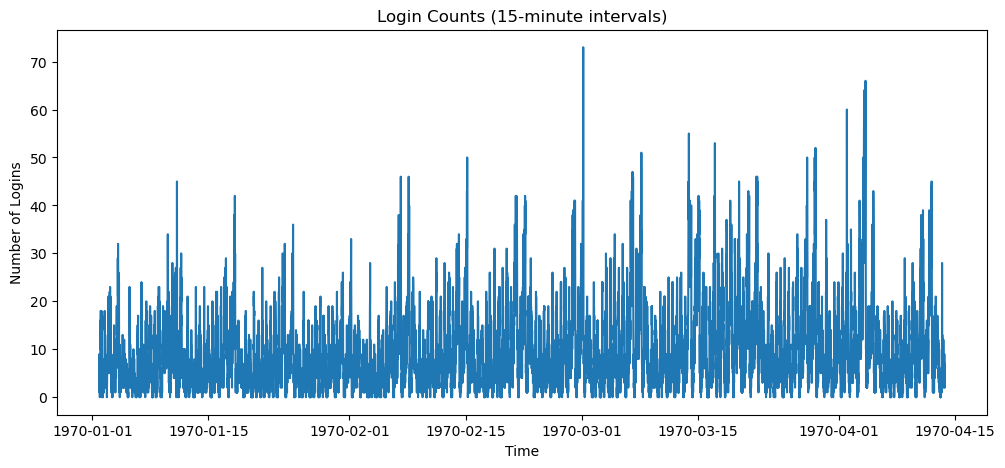

In [8]:
plt.figure(figsize=(12,5))
plt.plot(login_counts)
plt.title("Login Counts (15-minute intervals)")
plt.xlabel("Time")
plt.ylabel("Number of Logins")
plt.show()

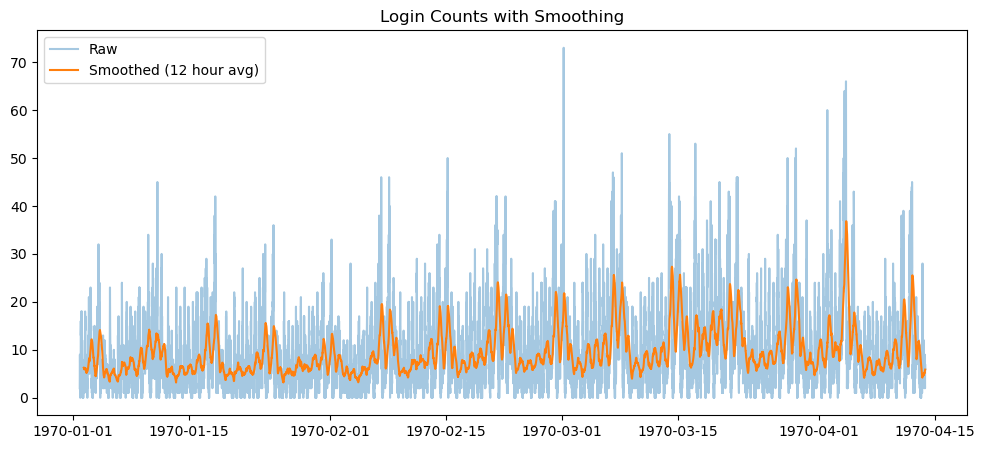

In [16]:
rolling = login_counts.rolling(window=48).mean()  # 12 hour smoothing

plt.figure(figsize=(12,5))
plt.plot(login_counts, alpha=0.4, label="Raw")
plt.plot(rolling, label="Smoothed (12 hour avg)")
plt.legend()
plt.title("Login Counts with Smoothing")
plt.show()

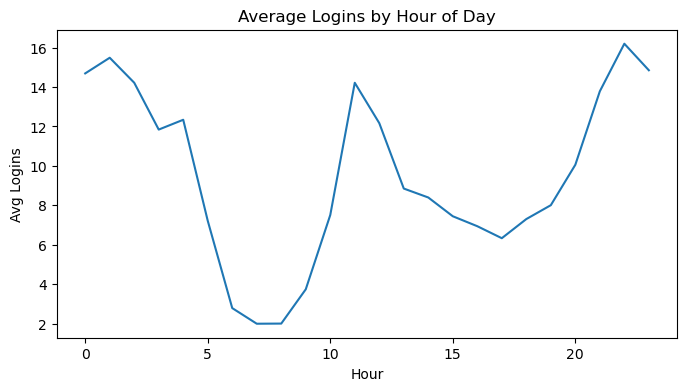

In [15]:
login_counts_by_hour = login_counts.groupby(login_counts.index.hour).mean()

plt.figure(figsize=(8,4))
plt.plot(login_counts_by_hour)
plt.title("Average Logins by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Avg Logins")
plt.show()

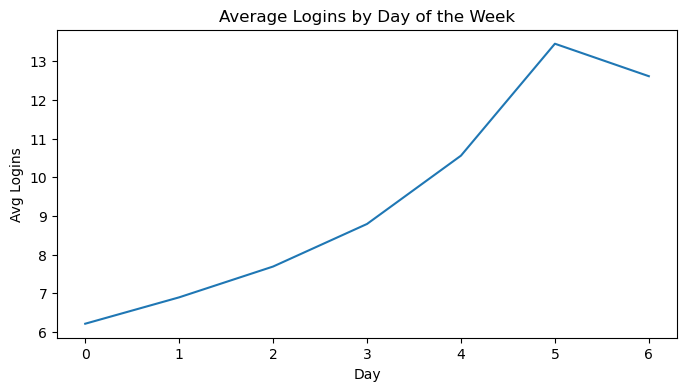

In [17]:
login_counts_by_day = login_counts.groupby(login_counts.index.dayofweek).mean()

plt.figure(figsize=(8,4))
plt.plot(login_counts_by_day)
plt.title("Average Logins by Day of the Week")
plt.xlabel("Day")
plt.ylabel("Avg Logins")
plt.show()

## Conclusion

The login time series (aggregated in 15-minute intervals) shows clear patterns in user demand.

- **Daily pattern:** Low usage in the early morning (5–7 AM) and higher activity during the day and evening.
- **Peak hours:** There are two main peaks — late morning (10 AM–12 PM) and late evening (9–11 PM), suggesting both daytime and nighttime engagement.
- **Weekly pattern:** Activity increases toward the weekend, with Friday and Saturday showing the highest average login counts.